# Week 2 — FITS files, TESS data products, and light-curve basics

This notebook works with **CM Draconis (TIC 199574208)**, a bright **eclipsing / spectroscopic binary** observed by TESS. It:

1. Resolves the target in the **TIC** and finds **2-minute cadence** TESS timeseries observations via **MAST**.
2. Downloads the **Target Pixel File** (`*_tp.fits`) and the matching **SPOC light curve** (`*_lc.fits`) for one sector.
3. Builds a **simple manual aperture** from the median flux image and sums **FLUX** through that mask (classic aperture photometry).
4. Compares the result to **SPOC SAP_FLUX** (and optionally to photometry using the pipeline aperture bitmask from the FITS **APERTURE** extension).

In [2]:
%matplotlib inline

from pathlib import Path

from lightkurve import search_targetpixelfile, search_lightcurve
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astroquery.mast import Catalogs, Observations

/Users/csavva/Documents/Repositories/astro-research/.venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 1. Load TPF

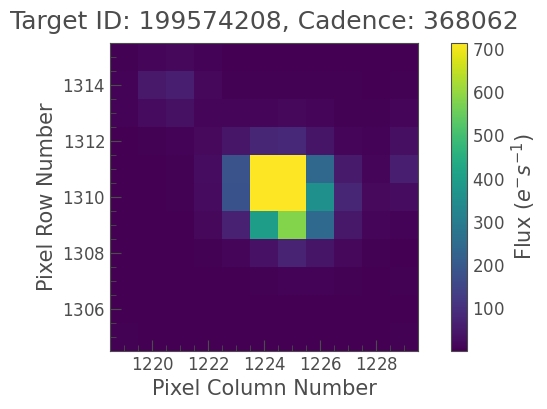

In [3]:
search_result = search_targetpixelfile('TIC 199574208', author="SPOC", cadence=120)
if len(search_result) > 0:
    tpf = search_result[0].download()
    tpf.plot(frame=0)


In [4]:
flux = tpf.flux
pm = tpf.pipeline_mask
t = tpf.time

## 2. Manual aperture photometry

In [5]:
# Apply quality mask
quality_mask = tpf.quality == 0
flux_clean = flux.value[quality_mask]
bkg_clean = tpf.flux_bkg.value[quality_mask]
t_clean = t.value[quality_mask]

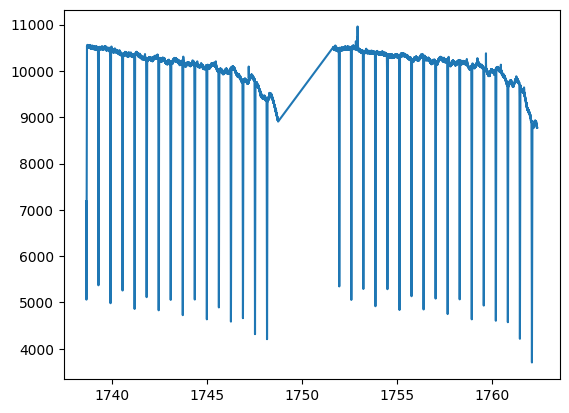

In [6]:
# Custom aperture photometry
median_frame = np.nanmedian(flux_clean, axis=0)
custom_mask = median_frame > np.percentile(median_frame, 85)

flux_at_each_time = np.nansum((flux_clean - bkg_clean) * pm, axis=(1, 2))
plt.plot(t_clean, flux_at_each_time)


In [7]:
search_result_lc = search_lightcurve('TIC 199574208', author="SPOC", cadence=120)
if len(search_result_lc) > 0:
    lc = search_result_lc[0].download()


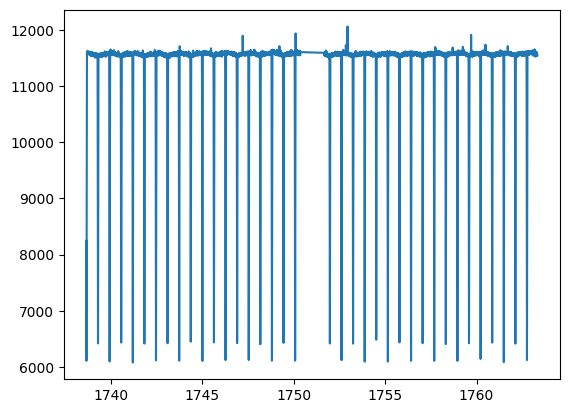

In [8]:
plt.plot(lc.time.value, lc.sap_flux.value)

In [9]:
lc_from_tpf = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)

Text(0.5, 0, 'BTJD')

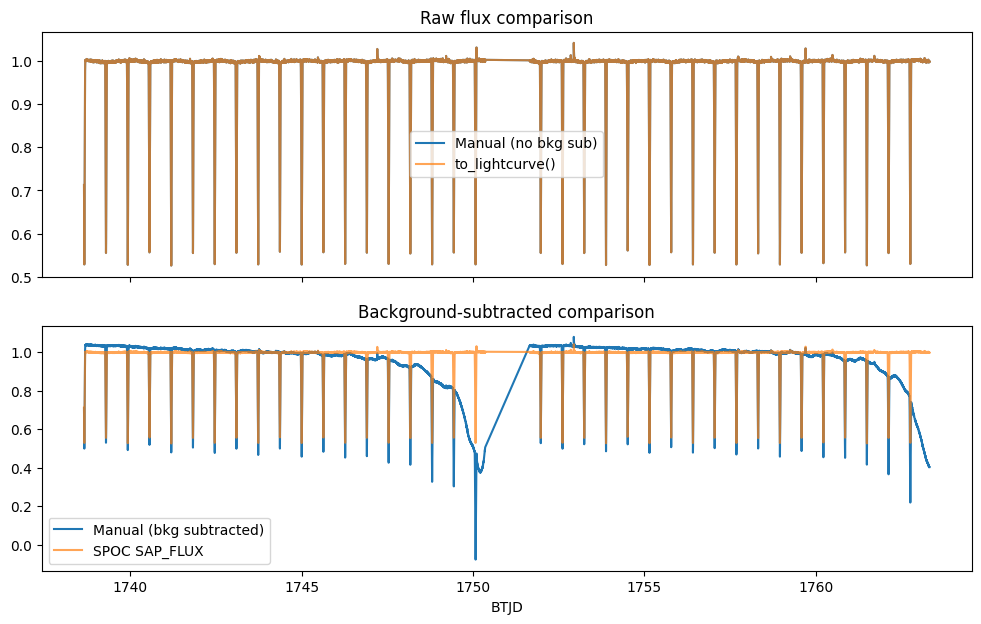

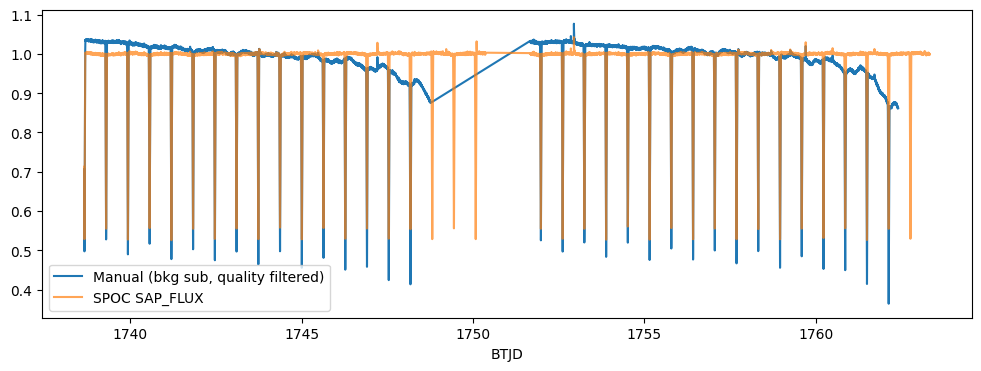

In [13]:
# No background subtraction — should match to_lightcurve()
flux_raw = np.nansum(flux.value * pm, axis=(1, 2))

# With background subtraction — should match SPOC SAP_FLUX
flux_bkg_sub = np.nansum((flux.value - tpf.flux_bkg.value) * pm, axis=(1, 2))

lc_from_tpf = tpf.to_lightcurve(aperture_mask='pipeline')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: raw comparison
axes[0].plot(t.value, flux_raw / np.nanmedian(flux_raw), label='Manual (no bkg sub)')
axes[0].plot(lc_from_tpf.time.value, lc_from_tpf.flux.value / np.nanmedian(lc_from_tpf.flux.value), label='to_lightcurve()', alpha=0.7)
axes[0].legend()
axes[0].set_title('Raw flux comparison')

# Bottom: bkg-subtracted vs SPOC SAP
axes[1].plot(t.value, flux_bkg_sub / np.nanmedian(flux_bkg_sub), label='Manual (bkg subtracted)')
axes[1].plot(lc.time.value, lc.sap_flux.value / np.nanmedian(lc.sap_flux.value), label='SPOC SAP_FLUX', alpha=0.7)
axes[1].legend()
axes[1].set_xlabel('BTJD')
axes[1].set_title('Background-subtracted comparison')

mask = tpf.quality == 0
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t.value[mask], flux_bkg_sub[mask] / np.nanmedian(flux_bkg_sub[mask]), 
        label='Manual (bkg sub, quality filtered)')
ax.plot(lc.time.value, lc.sap_flux.value / np.nanmedian(lc.sap_flux.value), 
        label='SPOC SAP_FLUX', alpha=0.7)
ax.legend()
ax.set_xlabel('BTJD')